# 1. From a Task to a Flow: Silicon band structure

Every calculation in AbiPy is, at bottom, an `AbinitTask`: one `AbinitInput`
plus a working directory. `Task`s can depend on each other (e.g. a
non-self-consistent run needs the density from a self-consistent one), and
a `Flow` is what takes care of that bookkeeping for you -- ordering tasks
correctly, and letting you (re)launch the whole thing with one command.

This notebook builds the same calculation -- the band structure of silicon
-- three times, in increasingly automated ways. Each step corresponds to
one standalone script in `../Examples/`; rather than printing the whole
script, we'll look at the `workshop_lib.py` function(s) it's generated
from (with `wlib.print_source`), build the same object directly here,
then look at the result of actually running it (each has already been run
for you):

Standalone scripts:

* `run_si_gstate.py` -- a single Task (ground state).
* `run_si_nscf.py` -- a second Task, depending on the first through a **hardcoded path**.
* `run_si_ebands.py` -- both tasks registered in a `Flow`, with the dependency expressed **through the task object itself**.
* `make_si_ebands.py` -- build the flow now, run it later.


In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from abipy import abilab
import abipy.flowtk as flowtk
abilab.enable_notebook()

%matplotlib inline

import workshop_lib as wlib

## 1.1 Ground-state density as a single Task

The simplest possible unit of work: one `AbinitInput` wrapped in one
`AbinitTask`, built and run directly -- no `Flow`, no `Work`.


In [5]:
wlib.print_source(wlib.si_gs_input)
wlib.print_source(wlib.build_si_gs_task)
wlib.print_source(wlib.setup_task_manager)

In [8]:
task = wlib.build_si_gs_task(workdir="task_si_gstate")
task = wlib.setup_task_manager(task, mpi_procs=4, timelimit_hour=0.1)

In [6]:

# Remove a previous run, if it exists.
if Path(task.workdir).exists():
    print(f'Removing existing directory: {task.workdir}/')
    task.rmtree()

task.build()
task.make_links()

In [10]:
task.start_and_wait()

0

In [11]:
task.check_status()

<Status: Completed, at 5366225168>

In [15]:
with abilab.abiopen("task_si_gstate/outdata/out_GSR.nc") as gsr:
    print("energy:", gsr.energy, "eV")

energy: -229.77702155478488 eV eV


## 1.2 Band structure calculation in a second, dependent Task

Same idea, but this task's input is a band-structure (NSCF) calculation,
and it needs the density file produced in Step 1.


In [16]:
wlib.print_source(wlib.si_bandstructure_input)
wlib.print_source(wlib.build_si_nscf_task)

Notice the dependency: `deps = {density: 'DEN'}`, where `density` is just
the **string path** to Step 1's density file. This works, but it's
fragile -- rename or move `task_si_gstate/`, and this breaks with no
warning until Abinit complains about a missing file.

In [20]:
task = wlib.build_si_nscf_task(workdir="task_si_nscf", density="task_si_gstate/outdata/out_DEN.nc")
task = wlib.setup_task_manager(task, mpi_procs=4, timelimit_hour=0.1)

Now run the task

In [21]:
# Remove a previous run, if it exists.
if Path(task.workdir).exists():
    print(f'Removing existing directory: {task.workdir}/')
    task.rmtree()

task.build()
task.make_links()

Removing existing directory: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/task_si_nscf/


In [22]:
task.start_and_wait()

0

In [23]:
task.check_status()

<Status: Completed, at 5366225168>

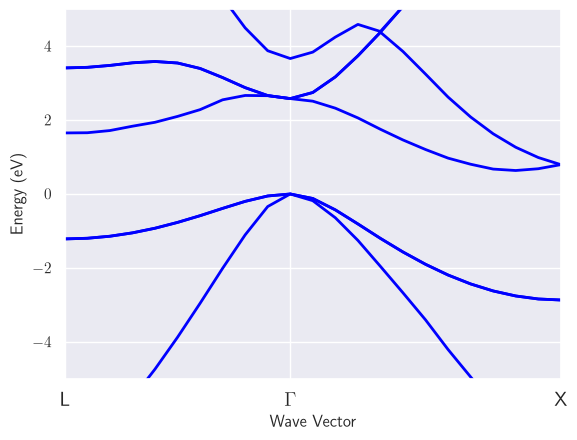

In [26]:
with abilab.abiopen("task_si_nscf/outdata/out_GSR.nc") as gsr:
    ebands = gsr.ebands

fig = ebands.plot(color="b", ylims=(-5,5), show=True)

## 1.3 Wrapping both Tasks in a Flow

Same two tasks, same physics -- but now registered together in a `Work`
inside a `Flow`, with the dependency expressed as `deps={gs_task: 'DEN'}`:
a reference to the *task object* itself, not a path. `si_gs_input`,
`build_si_gs_task`, `si_bandstructure_input` and `build_si_nscf_task` are
exactly the same functions shown in Steps 1-2; the only new piece is how
they're wrapped:


In [43]:
wlib.print_source(wlib.build_si_ebands_task_flow)
wlib.print_source(wlib.setup_manager)

### Build it, run it

In [44]:
flow = wlib.build_si_ebands_task_flow(workdir='flow_si_ebands')

In [45]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)

In [47]:
# Remove a previous run, if it exists.
if Path(flow.workdir).exists():
    print(f'Removing existing directory: {flow.workdir}/')
    flow.rmtree()

Removing existing directory: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_si_ebands/


In [48]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_si_ebands


In [49]:
# Run each of the tasks sequentially and wait for the result.
for work in flow:
    for task in work:
        task.start_and_wait()

        # Report calculation status
        print(f'Status of task {task.name}: {task.check_status()}')

Status of task w0_t0: Completed
Status of task w0_t1: Completed


If you see that both tasks are Completed, you can plot the band structure right away.
But consider the following approach, where we wait 

### Build now, run later

In [52]:
flow = wlib.build_si_ebands_task_flow(workdir='flow_si_ebands')
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)

In [56]:
# Remove a previous run, if it exists.
if Path(flow.workdir).exists():
    print(f'Removing existing directory: {flow.workdir}/')
    flow.rmtree()

Removing existing directory: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_si_ebands/


In [57]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_si_ebands


In [58]:
wlib.shell_command("abirun.py flow_si_ebands scheduler", silent=True)

In [63]:
# Run this cell several times to see progress
wlib.shell_command('abirun.py flow_si_ebands status')

### Plot the band structure

In [64]:
wlib.print_source(wlib.plot_ebands)

Running on Eudora.cgocable.ca -- system Darwin -- Python 3.12.3 -- abirun-0.9.8

Work #0: <Work, node_id=1615, workdir=flow_si_ebands/w0>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

all_ok reached



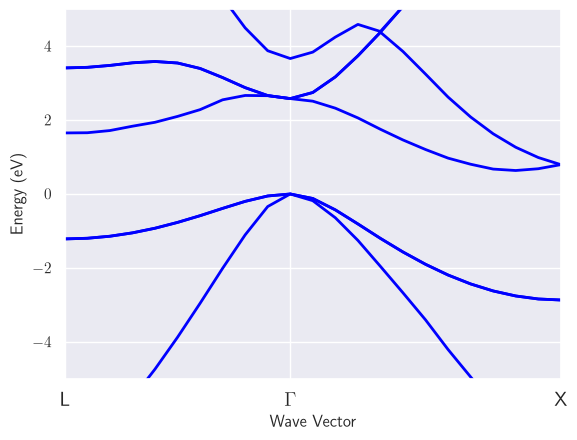

In [66]:
# Display resulting figure
fig = wlib.plot_ebands('flow_si_ebands', figname='', ylims=(-5,5), show=True)